In [1]:
import re
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from pydantic.v1 import BaseModel

load_dotenv()

C:\Users\moury\AppData\Local\Temp\ipykernel_27364\887336109.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

In [2]:
docs=(
    PyPDFLoader("./documents/book1.pdf").load()+
    PyPDFLoader("./documents/book2.pdf").load()+
    PyPDFLoader("./documents/book3.pdf").load()
)

In [3]:
len(docs)

2123

In [4]:
chunks=RecursiveCharacterTextSplitter(chunk_size=900,chunk_overlap=150).split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8","ignore").decode("utf-8","ignore")

In [5]:
len(chunks)

6685

In [6]:
embeddings=OpenAIEmbeddings(model="text-embedding-3-large")
vector_store=FAISS.from_documents(chunks,embeddings)

In [7]:
retriever=vector_store.as_retriever(search_type='similarity',seach_kwargs={"k":4})

In [8]:
llm=ChatOpenAI(model="gpt-4o-mini",temperature=0)

In [9]:
UPPER_TH=0.7
LOWER_TH=0.3

In [10]:
class State(TypedDict):
    question:str
    docs:List[Document]
    answer:str

    strips:List[str]
    kept_strips:List[str]
    refined_context:str

    good_docs:List[Document]
    verdict:str
    reason:str

In [11]:
def retrieve(state):
    q=state['question']

    return {"docs":retriever.invoke(q)}

In [14]:
class DocEvalScore(BaseModel):
    score:float
    reason:str

doc_eval_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain=doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def eval_each_doc_node(state:State)->State:

    q=state['question']

    scores:List[float]=[]
    reasons:List[str]=[]
    good:List[Document]=[]

    for d in state['docs']:
        out=doc_eval_chain.invoke({"question":q,"chunk":d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        if out.score>LOWER_TH:
            good.append(d)

    if any(s>UPPER_TH for s in scores):
        return {
            "good_docs":good,
            "verdict":"CORRECT",
            "reason":f"At least one retrieved chunk scored > {UPPER_TH}"
        }

    if len(scores)>0 and all(s<LOWER_TH for s in scores):
        why="NO chunk was sufficient."

        return {
            "good_docs":[],
            "verdict":"INCORRECT",
            "reason":f"All retrieved chunks scored < {LOWER_TH}.{why}",
        }

    why="Mixed relevance signals"

    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}",
    }

In [15]:
def decompose_to_sentence(text:str)->List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)

    return [s.strip() for s in sentences if len(s.strip())> 20]

class KeepOrDrop(BaseModel):
    keep:bool

filter_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain= filter_prompt | llm.with_structured_output(KeepOrDrop)

def refine(state:State) -> State:
    q=state["question"]

    context="\n\n".join(d.page_content for d in state['docs']).strip()

    strips=decompose_to_sentence(context)

    kept:List[str]=[]

    for s in strips:
        if filter_chain.invoke({"question":q,"sentence":s}).keep:
            kept.append(s)

    refined_context="\n".join(kept).strip()

    return {
        "strips":strips,
        "kept_strips":kept,
        "refined_context":refined_context,
    }

In [16]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

In [18]:
def fail_node(state: State) -> State:
    return {"answer": f"FAIL: {state['reason']}"}

def ambiguous_node(state: State) -> State:
    return {"answer": f"Ambiguous: {state['reason']}"}

def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    elif state["verdict"] == "INCORRECT":
        return "web_search"
    else:
        return "ambiguous"

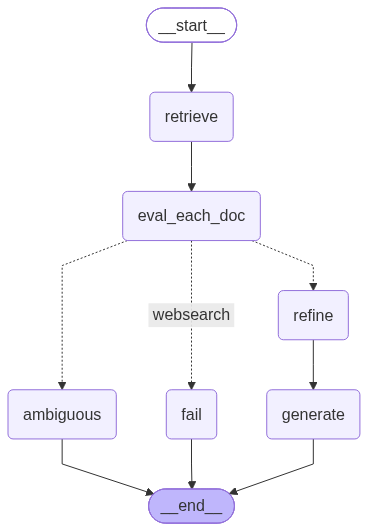

In [19]:
g=StateGraph(State)
g.add_node("retrieve",retrieve)
g.add_node("eval_each_doc",eval_each_doc_node)
g.add_node("refine",refine)
g.add_node("generate",generate)
g.add_node("fail",fail_node)
g.add_node("ambiguous",ambiguous_node)

g.add_edge(START,"retrieve")
g.add_edge("retrieve","eval_each_doc")
g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {"refine":"refine","websearch":"fail","ambiguous":"ambiguous"}
)
g.add_edge("refine","generate")
g.add_edge("generate",END)
g.add_edge("fail",END)
app=g.compile()

app

In [22]:
res = app.invoke(
    {
        "question": "Bias Variance Tradeoff",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])


VERDICT: CORRECT
REASON: At least one retrieved chunk scored > 0.7

OUTPUT:
 - Bias and variance measure two different sources of error in an estimator.
- Bias measures the expected deviation from the true value of the function or parameter.
- Variance measures the deviation from the expected estimator value caused by sampling variations.
- When choosing between two estimators, one with more bias and one with more variance, cross-validation is commonly used to negotiate the trade-off.
- The goal is to minimize expected loss, which is the sum of squared bias, variance, and a constant noise term.
- There is a trade-off between bias and variance: flexible models have low bias and high variance, while rigid models have high bias and low variance.
- The optimal model balances bias and variance for the best predictive capability.
- Generalization error can be expressed as the sum of bias, variance, and noise.
- High-bias models tend to underfit the training data, while high-variance models a

In [23]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

5.4.4 TradingoﬀBiasandVariancetoMinimize MeanSquared
Error
Bias and variance measure two diﬀerent sources of error in an estimator. Bias
measures the expected deviation from the true value of the function or parameter.
Variance on the other hand, provides a measure of the deviation from the expected
estimator value that any particular sampling of the data is likely to cause.
What happens when we are given a choice between two estimators, one with
more bias and one with more variance? How do we choose between them? For
example, imagine that we are interested in approximating the function shown in
ﬁgure and we are only oﬀered the choice between a model with large bias and5.2
one that suﬀers from large variance. How do we choose between them?
The most common way to negotiate this trade-oﬀ is to use cross-validation.
****************************************************************************************************
and the bias and variance terms now refer to integrated quantities.
Our go

In [23]:
print(res['refined_context'])

5.4.4 TradingoﬀBiasandVariancetoMinimize MeanSquared Error Bias and variance measure two diﬀerent sources of error in an estimator.
Bias measures the expected deviation from the true value of the function or parameter.
What happens when we are given a choice between two estimators, one with more bias and one with more variance?
For example, imagine that we are interested in approximating the function shown in ﬁgure and we are only oﬀered the choice between a model with large bias and5.2 one that suﬀers from large variance.
The Bias/Variance Tradeoff An importan t theoretical result of statistics and Machine Learning is the fact that a model’s generaliza tion error can be expressed as the sum of three very different errors: Bias This part of the generalization error is due to wrong assumptions, such as assum‐ ing that the data is linear when it is actually quadratic.
A high-bias model is most likely to underfit the training data.10 Variance This part is due to the model’s excessive sens